# Credit Card Default Prediction

When a bank issues a credit card, the customer borrows money to make purchases
and receives a monthly statement. The customer must meet the payment terms for that account by the due date.

A model is created to predict a customer's tedency to default from the given dataset.

This notebook documents the complete pipeline used to generate the final submission, including data preprocessing, feature engineering, model validation, model comparison, final training and test-set inference.

In [34]:
import time
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "default"
ID_COLUMN = "client_id"
TRAIN_PATH = Path("train.csv")
TEST_PATH = Path("test.csv")
SUBMISSION_PATH = Path("submission.csv")

REPAYMENT_COLUMNS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
BILL_COLUMNS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAYMENT_COLUMNS = [f"PAY_AMT{i}" for i in range(1, 7)]
CATEGORICAL_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE", *REPAYMENT_COLUMNS]
RAW_NUMERIC_COLUMNS = ["LIMIT_BAL", "AGE", *BILL_COLUMNS, *PAYMENT_COLUMNS]
MODEL_FEATURE_COLUMNS = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    *REPAYMENT_COLUMNS, *BILL_COLUMNS, *PAYMENT_COLUMNS,
]
EXPECTED_TRAIN_COLUMNS = [ID_COLUMN, *MODEL_FEATURE_COLUMNS, TARGET]

In [35]:
def validate_training_data(data):
    """Validate the labeled data contract before any analysis or modeling."""
    if data.columns.tolist() != EXPECTED_TRAIN_COLUMNS:
        raise ValueError("Unexpected training column order or schema")
    if not data[ID_COLUMN].is_unique:
        raise ValueError("Client IDs must be unique")
    if not data[TARGET].isin([0, 1]).all():
        raise ValueError(f"{TARGET!r} must contain only 0 and 1")
    if data.isna().any().any():
        raise ValueError("Training data contains missing values")
    if not np.isfinite(data[MODEL_FEATURE_COLUMNS].to_numpy(dtype=float)).all():
        raise ValueError("Training features must be finite")
    if data["LIMIT_BAL"].le(0).any():
        raise ValueError("LIMIT_BAL must be positive")


if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Could not find {TRAIN_PATH.resolve()}")

train_df = pd.read_csv(TRAIN_PATH)
validate_training_data(train_df)

print(f"Shape: {len(train_df):,} rows x {train_df.shape[1]} columns")
print(f"Missing cells: {int(train_df.isna().sum().sum()):,}")
print(f"Default rate: {train_df[TARGET].mean():.2%}")
display(train_df[TARGET].value_counts().rename_axis(TARGET).to_frame("count"))

Shape: 24,000 rows x 25 columns
Missing cells: 0
Default rate: 22.12%


,count
default,
0,18691
1,5309


## Exploratory Data Analysis

This section checks data quality, target prevalence, repayment-status risk, credit-limit tiers, bill correlations, and subgroup patterns before feature engineering.

In [36]:
duplicate_feature_rows = int(
    train_df.drop(columns=[ID_COLUMN, TARGET]).duplicated().sum()
)

print(f"Feature columns: {len(MODEL_FEATURE_COLUMNS)}")
print(f"Duplicate feature rows, ignoring ID and target: {duplicate_feature_rows}")

Feature columns: 23
Duplicate feature rows, ignoring ID and target: 41


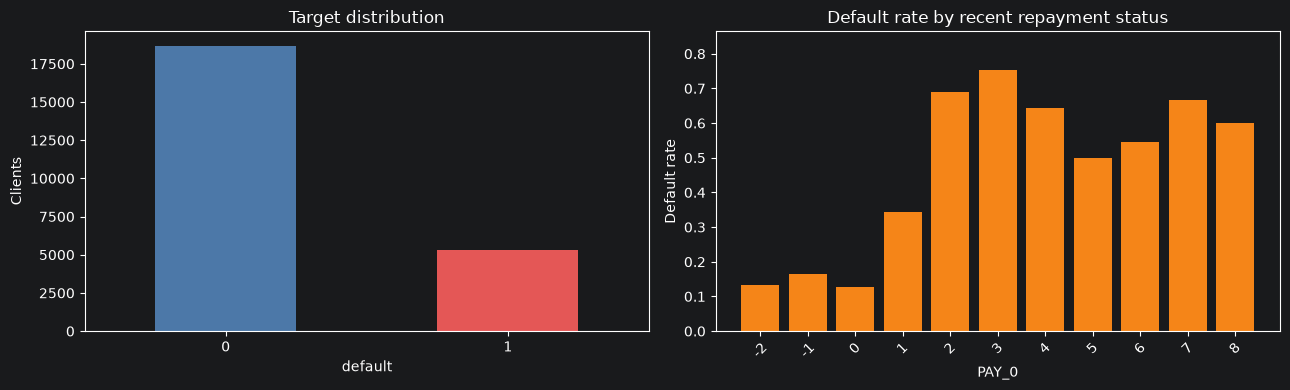

In [37]:
target_summary = train_df[TARGET].value_counts().sort_index().rename_axis(TARGET).to_frame("clients")

recent_status_summary = (
    train_df.groupby("PAY_0")[TARGET]
    .agg(clients="size", default_rate="mean")
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
target_summary["clients"].plot.bar(ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set(
    title="Target distribution",
    xlabel=TARGET,
    ylabel="Clients",
)
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(
    recent_status_summary.index.astype(str),
    recent_status_summary["default_rate"],
    color="#F58518",
)
axes[1].set(
    title="Default rate by recent repayment status",
    xlabel="PAY_0",
    ylabel="Default rate",
    ylim=(0, min(1, recent_status_summary["default_rate"].max() * 1.15)),
)
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

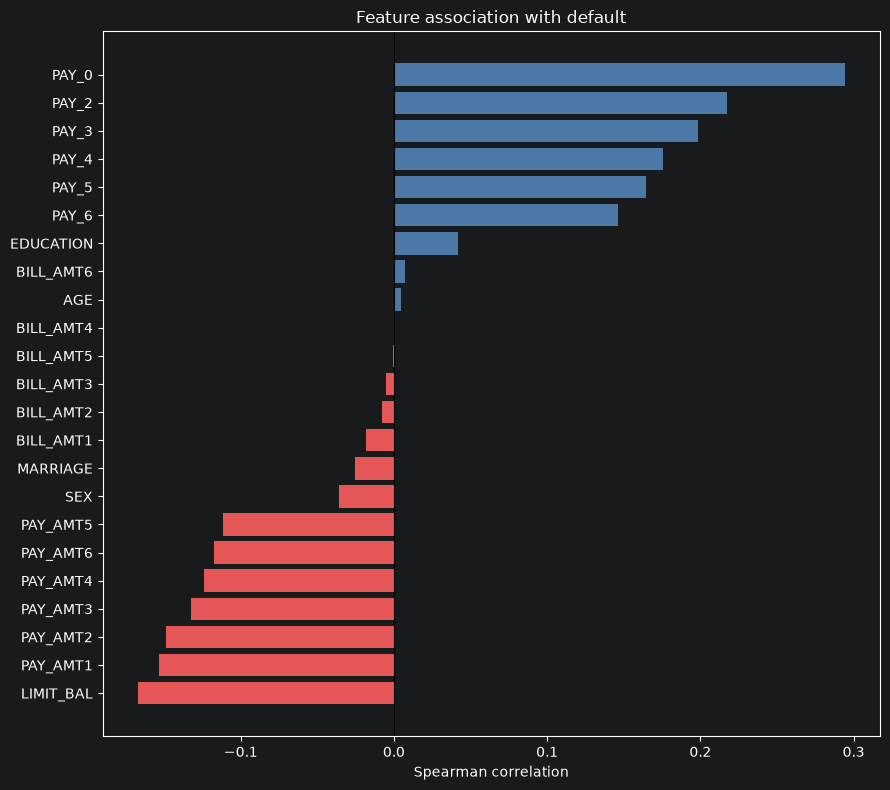

In [38]:
screening_columns = train_df.select_dtypes(include="number").columns.drop(TARGET)
target_spearman = (
    train_df[screening_columns]
    .corrwith(train_df[TARGET], method="spearman")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 8))
colors = np.where(target_spearman.lt(0), "#E45756", "#4C78A8")
ax.barh(target_spearman.index, target_spearman.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Feature association with default",
    xlabel="Spearman correlation",
    ylabel="",
)
fig.tight_layout()
plt.show()

## Validation Framework and Metric Selection

This phase separates an untouched final holdout from development cross-validation and defines probability-based metric before model training.

In [39]:
X_all = train_df[MODEL_FEATURE_COLUMNS].copy()
y_all = train_df[TARGET].copy()

HOLDOUT_SIZE = 0.20
N_SPLITS = 5

X_development, X_holdout, y_development, y_holdout = train_test_split(
    X_all,
    y_all,
    test_size=HOLDOUT_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE,
)
CV = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

assert set(X_development.index).isdisjoint(X_holdout.index)
assert len(X_development) + len(X_holdout) == len(X_all)

fold_rows = []
for fold_number, (train_positions, validation_positions) in enumerate(
    CV.split(X_development, y_development),
    start=1,
):
    fold_rows.append(
        {
            "fold": fold_number,
            "train_rows": len(train_positions),
            "validation_rows": len(validation_positions),
            "train_default_rate": y_development.iloc[train_positions].mean(),
            "validation_default_rate": y_development.iloc[validation_positions].mean(),
        }
    )

split_summary = pd.DataFrame(fold_rows)
print(f"Development rows: {len(X_development):,}")
print(f"Final holdout rows: {len(X_holdout):,}")
print(f"Development default rate: {y_development.mean():.2%}")
print(f"Holdout default rate: {y_holdout.mean():.2%}")
display(split_summary.round({"train_default_rate": 4, "validation_default_rate": 4}))

Development rows: 19,200
Final holdout rows: 4,800
Development default rate: 22.12%
Holdout default rate: 22.12%


,fold,train_rows,validation_rows,train_default_rate,validation_default_rate
0,1,15360,3840,0.2212,0.2211
1,2,15360,3840,0.2212,0.2211
2,3,15360,3840,0.2212,0.2211
3,4,15360,3840,0.2212,0.2214
4,5,15360,3840,0.2212,0.2214


In [40]:
PROBABILITY_EPSILON = 1e-15


def evaluate_probabilities(y_true, probabilities):
    """Return the competition metric and supporting probability diagnostics."""
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities, dtype=float)

    if probabilities.shape != y_true.shape:
        raise ValueError("y_true and probabilities must have the same shape")
    if not np.isfinite(probabilities).all():
        raise ValueError("Probabilities must be finite")
    if ((probabilities < 0) | (probabilities > 1)).any():
        raise ValueError("Probabilities must be between 0 and 1")

    probabilities = np.clip(
        probabilities,
        PROBABILITY_EPSILON,
        1 - PROBABILITY_EPSILON,
    )
    return {
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
    }


def generate_cv_predictions(estimator, X_data, y_data, X_predict, cv=CV):
    """Collect OOF and averaged held-out probabilities from the same fold fits."""
    oof_probabilities = np.full(len(y_data), np.nan)
    averaged_probabilities = np.zeros(len(X_predict))
    n_splits = cv.get_n_splits(X_data, y_data)

    for train_positions, validation_positions in cv.split(X_data, y_data):
        fold_estimator = deepcopy(estimator)
        fold_estimator.fit(
            X_data.iloc[train_positions],
            y_data.iloc[train_positions],
        )
        oof_probabilities[validation_positions] = fold_estimator.predict_proba(
            X_data.iloc[validation_positions]
        )[:, 1]
        averaged_probabilities += fold_estimator.predict_proba(X_predict)[:, 1] / n_splits

    if np.isnan(oof_probabilities).any():
        raise RuntimeError("OOF prediction array contains unfilled positions")
    return oof_probabilities, averaged_probabilities


development_prevalence = y_development.mean()
baseline_probabilities = np.full(len(y_development), development_prevalence)
baseline_metrics = evaluate_probabilities(y_development, baseline_probabilities)

print(f"Development prevalence baseline probability: {development_prevalence:.4f}")
print("The final holdout is reserved until model and calibration selection are complete.")
display(pd.DataFrame([baseline_metrics], index=["prevalence_baseline"]).round(4))

Development prevalence baseline probability: 0.2212
The final holdout is reserved until model and calibration selection are complete.


,log_loss,brier_score,roc_auc,average_precision
prevalence_baseline,0.5284,0.1723,0.5,0.2212


## Data Cleaning and Preprocessing

This phase standardizes category codes and defines a reusable preprocessing pipeline. The transformer is fitted on development data only so the final holdout remains untouched.

In [41]:
class CategoryCleaner(BaseEstimator, TransformerMixin):
    """Group undocumented demographic codes and retain audit indicators."""

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CategoryCleaner expects a pandas DataFrame")
        self.feature_names_in_ = X.columns.to_numpy()
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CategoryCleaner expects a pandas DataFrame")
        if not hasattr(self, "feature_names_in_"):
            raise RuntimeError("CategoryCleaner must be fitted before transform")
        if X.columns.tolist() != list(self.feature_names_in_):
            raise ValueError("Input columns must match the columns observed during fit")

        data = X.copy()
        education_valid = data["EDUCATION"].isin([1, 2, 3, 4])
        marriage_valid = data["MARRIAGE"].isin([1, 2, 3])
        data["EDUCATION_UNKNOWN"] = (~education_valid).astype("int8")
        data["MARRIAGE_UNKNOWN"] = (~marriage_valid).astype("int8")
        data["EDUCATION"] = data["EDUCATION"].where(education_valid, 4)
        data["MARRIAGE"] = data["MARRIAGE"].where(marriage_valid, 3)
        return data


CLEANING_INDICATOR_COLUMNS = ["EDUCATION_UNKNOWN", "MARRIAGE_UNKNOWN"]
BASE_NUMERIC_COLUMNS = [*RAW_NUMERIC_COLUMNS, *CLEANING_INDICATOR_COLUMNS]


def make_dense_preprocessor():
    """Build shared dense preprocessing for calibrated HGB and logistic regression."""
    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return Pipeline(
        [
            ("clean_categories", CategoryCleaner()),
            (
                "columns",
                ColumnTransformer(
                    transformers=[
                        (
                            "numeric",
                            numeric_pipeline,
                            [*BASE_NUMERIC_COLUMNS, *ENGINEERED_COLUMNS],
                        ),
                        (
                            "categorical",
                            categorical_pipeline,
                            CATEGORICAL_COLUMNS,
                        ),
                    ],
                    remainder="drop",
                    verbose_feature_names_out=False,
                ),
            ),
        ]
    )

## Financial Domain Feature Engineering

This section creates the following features:
- **Payment-to-bill dynamics**: Matched ratios (PAY_AMT1 against BILL_AMT2 through PAY_AMT5 against BILL_AMT6), same-month ratios, payment-in-full flags, zero payment on positive balances, and underpayment indicators (< 5% minimum payment).
- **Credit limit exhaustion**: Credit utilization across all months, overlimit indicators and counts, available credit amount and ratio, and limit-to-age interaction.
- **Delinquency trajectory**: Explicit ordinal indicators (late, severe, paid), delinquency velocity and acceleration, consecutive late streaks leading to current status, and PAY_0 interaction features.
- **Cashflow deficit & trend**: Total debt vs total payments, cumulative deficit, scissors effect (growing bill with shrinking payment), and trajectory slope.


In [42]:
class FinancialFeatureBuilder(BaseEstimator, TransformerMixin):
    """Create timing-safe, high-signal financial features from account history."""

    @staticmethod
    def _ratio_to_positive_denominator(numerator, denominator):
        return (
            numerator.div(denominator.where(denominator.gt(0)))
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
        )

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("FinancialFeatureBuilder expects a pandas DataFrame")
        self.feature_names_in_ = X.columns.to_numpy()
        self.engineered_columns_ = self.engineered_column_names()
        return self

    @staticmethod
    def engineered_column_names():
        names = [
            "LOG_LIMIT_BAL",
            "LIMIT_PER_AGE",
            "BILL1_PER_AGE",
            "AVAILABLE_CREDIT_1",
            "AVAILABLE_RATIO_1",
            "OVERLIMIT_COUNT",
            "ZERO_PAY_COUNT",
            "PAID_FULL_COUNT",
            "UNDERPAID_COUNT",
            "DELINQUENCY_CURRENT_VS_PRIOR",
            "DELINQUENCY_ACCELERATION",
            "DELINQUENCY_MAX",
            "DELINQUENCY_MIN",
            "DELINQUENT_MONTH_COUNT",
            "SEVERE_DELINQUENT_MONTH_COUNT",
            "DELINQUENCY_MEAN",
            "DELINQUENCY_STD",
            "CONSECUTIVE_LATE_STREAK",
            "PAY0_TIMES_UTILIZATION_1",
            "PAY0_TIMES_LIMIT",
            "HIGH_RISK_COMBO",
            "BILL_MEAN",
            "BILL_STD",
            "BILL_MAX",
            "BILL_MIN",
            "BILL_TOTAL",
            "BILL_SLOPE",
            "BILL_RECENT_MINUS_HISTORY",
            "BILL_RECENT_TO_HISTORY_RATIO",
            "BILL_HISTORY_NONPOSITIVE",
            "PAYMENT_TOTAL",
            "PAYMENT_MEAN",
            "PAYMENT_STD",
            "PAYMENT_MAX",
            "PAYMENT_MIN",
            "PAYMENT_ZERO_COUNT",
            "PAYMENT_RECENT_MINUS_HISTORY",
            "PAYMENT_RECENT_TO_HISTORY_RATIO",
            "PAYMENT_HISTORY_NONPOSITIVE",
            "UTILIZATION_MEAN",
            "UTILIZATION_MAX",
            "UTILIZATION_RECENT_MEAN",
            "CUMULATIVE_DEFICIT",
            "TOTAL_PAY_TO_BILL_RATIO",
            "SCISSORS_EFFECT_1",
        ]
        for month in range(1, 7):
            names.extend([
                f"UTILIZATION_{month}",
                f"OVERLIMIT_{month}",
                f"BILL_NEGATIVE_{month}",
                f"SAME_MONTH_PAY_RATIO_{month}",
            ])
        for month in range(1, 6):
            names.extend([
                f"PAY_RATIO_{month}",
                f"PAY_RATIO_{month}_REFERENCE_ZERO",
                f"PAY_RATIO_{month}_REFERENCE_NEGATIVE",
                f"PAY_RATIO_{month}_REFERENCE_UNAVAILABLE",
                f"DEFICIT_{month}",
                f"BILL_CHANGE_{month}",
                f"PAID_IN_FULL_{month}",
                f"ZERO_PAY_ACTIVE_BILL_{month}",
                f"UNDERPAID_MINIMUM_{month}",
            ])
        for col in REPAYMENT_COLUMNS:
            names.extend([
                f"{col}_IS_LATE",
                f"{col}_IS_SEVERE",
                f"{col}_IS_PAID",
            ])
        return names

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("FinancialFeatureBuilder expects a pandas DataFrame")
        limit = X["LIMIT_BAL"]
        age = X["AGE"]
        feats = {}

        feats["LOG_LIMIT_BAL"] = np.log1p(limit)
        feats["LIMIT_PER_AGE"] = limit / age
        feats["BILL1_PER_AGE"] = X["BILL_AMT1"] / age
        avail_cred = limit - X["BILL_AMT1"]
        feats["AVAILABLE_CREDIT_1"] = avail_cred
        feats["AVAILABLE_RATIO_1"] = (avail_cred / limit).clip(-5.0, 5.0)

        utilization = X[BILL_COLUMNS].div(limit, axis=0)
        overlimit_sum = pd.Series(0, index=X.index, dtype="int8")
        for m in range(1, 7):
            b = X[f"BILL_AMT{m}"]
            p = X[f"PAY_AMT{m}"]
            is_over = b.gt(limit).astype("int8")
            feats[f"UTILIZATION_{m}"] = utilization[f"BILL_AMT{m}"]
            feats[f"OVERLIMIT_{m}"] = is_over
            feats[f"BILL_NEGATIVE_{m}"] = b.lt(0).astype("int8")
            feats[f"SAME_MONTH_PAY_RATIO_{m}"] = self._ratio_to_positive_denominator(p, b)
            overlimit_sum += is_over
        feats["OVERLIMIT_COUNT"] = overlimit_sum

        zero_pay_sum = pd.Series(0, index=X.index, dtype="int8")
        paid_full_sum = pd.Series(0, index=X.index, dtype="int8")
        underpaid_sum = pd.Series(0, index=X.index, dtype="int8")

        for m in range(1, 6):
            payment = X[f"PAY_AMT{m}"]
            ref_bill = X[f"BILL_AMT{m + 1}"]
            valid_ref = ref_bill.gt(0)
            is_full = (payment >= ref_bill) & valid_ref
            is_zero = valid_ref & payment.eq(0)
            is_under = valid_ref & (payment < 0.05 * ref_bill)

            feats[f"PAY_RATIO_{m}"] = self._ratio_to_positive_denominator(payment, ref_bill)
            feats[f"PAY_RATIO_{m}_REFERENCE_ZERO"] = ref_bill.eq(0).astype("int8")
            feats[f"PAY_RATIO_{m}_REFERENCE_NEGATIVE"] = ref_bill.lt(0).astype("int8")
            feats[f"PAY_RATIO_{m}_REFERENCE_UNAVAILABLE"] = (~valid_ref).astype("int8")
            feats[f"DEFICIT_{m}"] = ref_bill - payment
            feats[f"BILL_CHANGE_{m}"] = X[f"BILL_AMT{m}"] - ref_bill
            feats[f"PAID_IN_FULL_{m}"] = is_full.astype("int8")
            feats[f"ZERO_PAY_ACTIVE_BILL_{m}"] = is_zero.astype("int8")
            feats[f"UNDERPAID_MINIMUM_{m}"] = is_under.astype("int8")

            paid_full_sum += is_full.astype("int8")
            zero_pay_sum += is_zero.astype("int8")
            underpaid_sum += is_under.astype("int8")

        feats["PAID_FULL_COUNT"] = paid_full_sum
        feats["ZERO_PAY_COUNT"] = zero_pay_sum
        feats["UNDERPAID_COUNT"] = underpaid_sum

        delinquency = X[REPAYMENT_COLUMNS]
        for col in REPAYMENT_COLUMNS:
            feats[f"{col}_IS_LATE"] = (X[col] > 0).astype("int8")
            feats[f"{col}_IS_SEVERE"] = (X[col] >= 2).astype("int8")
            feats[f"{col}_IS_PAID"] = (X[col] <= 0).astype("int8")

        feats["DELINQUENCY_CURRENT_VS_PRIOR"] = X["PAY_0"] - X["PAY_2"]
        feats["DELINQUENCY_ACCELERATION"] = (X["PAY_0"] - X["PAY_2"]) - (X["PAY_2"] - X["PAY_3"])
        feats["DELINQUENCY_MAX"] = delinquency.max(axis=1)
        feats["DELINQUENCY_MIN"] = delinquency.min(axis=1)
        feats["DELINQUENT_MONTH_COUNT"] = delinquency.gt(0).sum(axis=1)
        feats["SEVERE_DELINQUENT_MONTH_COUNT"] = delinquency.ge(2).sum(axis=1)
        feats["DELINQUENCY_MEAN"] = delinquency.mean(axis=1)
        feats["DELINQUENCY_STD"] = delinquency.std(axis=1).fillna(0.0)

        streak = (X["PAY_0"] > 0).astype("int8")
        streak += ((X["PAY_0"] > 0) & (X["PAY_2"] > 0)).astype("int8")
        streak += ((X["PAY_0"] > 0) & (X["PAY_2"] > 0) & (X["PAY_3"] > 0)).astype("int8")
        feats["CONSECUTIVE_LATE_STREAK"] = streak

        feats["PAY0_TIMES_UTILIZATION_1"] = X["PAY_0"] * feats["UTILIZATION_1"]
        feats["PAY0_TIMES_LIMIT"] = X["PAY_0"] * feats["LOG_LIMIT_BAL"]
        feats["HIGH_RISK_COMBO"] = ((X["PAY_0"] >= 2) & (feats["UTILIZATION_1"] > 0.8)).astype("int8")

        chronological_bills = X[BILL_COLUMNS[::-1]].to_numpy(dtype=float)
        time_index = np.arange(len(BILL_COLUMNS), dtype=float)
        centered_time = time_index - time_index.mean()

        feats["BILL_MEAN"] = X[BILL_COLUMNS].mean(axis=1)
        feats["BILL_STD"] = X[BILL_COLUMNS].std(axis=1).fillna(0.0)
        feats["BILL_MAX"] = X[BILL_COLUMNS].max(axis=1)
        feats["BILL_MIN"] = X[BILL_COLUMNS].min(axis=1)
        feats["BILL_TOTAL"] = X[BILL_COLUMNS].sum(axis=1)
        feats["BILL_SLOPE"] = (
            (chronological_bills * centered_time).sum(axis=1)
            / np.square(centered_time).sum()
        )

        recent_bills = X[BILL_COLUMNS[:3]].mean(axis=1)
        historical_bills = X[BILL_COLUMNS[3:]].mean(axis=1)
        feats["BILL_RECENT_MINUS_HISTORY"] = recent_bills - historical_bills
        feats["BILL_RECENT_TO_HISTORY_RATIO"] = self._ratio_to_positive_denominator(recent_bills, historical_bills)
        feats["BILL_HISTORY_NONPOSITIVE"] = (~historical_bills.gt(0)).astype("int8")

        recent_payments = X[PAYMENT_COLUMNS[:3]].mean(axis=1)
        historical_payments = X[PAYMENT_COLUMNS[3:]].mean(axis=1)
        feats["PAYMENT_TOTAL"] = X[PAYMENT_COLUMNS].sum(axis=1)
        feats["PAYMENT_MEAN"] = X[PAYMENT_COLUMNS].mean(axis=1)
        feats["PAYMENT_STD"] = X[PAYMENT_COLUMNS].std(axis=1).fillna(0.0)
        feats["PAYMENT_MAX"] = X[PAYMENT_COLUMNS].max(axis=1)
        feats["PAYMENT_MIN"] = X[PAYMENT_COLUMNS].min(axis=1)
        feats["PAYMENT_ZERO_COUNT"] = X[PAYMENT_COLUMNS].eq(0).sum(axis=1)
        feats["PAYMENT_RECENT_MINUS_HISTORY"] = recent_payments - historical_payments
        feats["PAYMENT_RECENT_TO_HISTORY_RATIO"] = self._ratio_to_positive_denominator(recent_payments, historical_payments)
        feats["PAYMENT_HISTORY_NONPOSITIVE"] = (~historical_payments.gt(0)).astype("int8")

        feats["UTILIZATION_MEAN"] = utilization.mean(axis=1)
        feats["UTILIZATION_MAX"] = utilization.max(axis=1)
        feats["UTILIZATION_RECENT_MEAN"] = utilization[BILL_COLUMNS[:3]].mean(axis=1)

        feats["CUMULATIVE_DEFICIT"] = feats["BILL_TOTAL"] - feats["PAYMENT_TOTAL"]
        feats["TOTAL_PAY_TO_BILL_RATIO"] = self._ratio_to_positive_denominator(feats["PAYMENT_TOTAL"], feats["BILL_TOTAL"])
        feats["SCISSORS_EFFECT_1"] = ((X["BILL_AMT1"] > X["BILL_AMT2"]) & (X["PAY_AMT1"] < X["PAY_AMT2"])).astype("int8")

        feat_df = pd.DataFrame(feats, index=X.index)
        return pd.concat([X, feat_df], axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(
            [*self.feature_names_in_, *self.engineered_columns_],
            dtype=object,
        )

In [43]:
ENGINEERED_COLUMNS = FinancialFeatureBuilder.engineered_column_names()

assert len(ENGINEERED_COLUMNS) == 132
assert len(ENGINEERED_COLUMNS) == len(set(ENGINEERED_COLUMNS))

print(f"Raw model features: {len(MODEL_FEATURE_COLUMNS)}")
print(f"Engineered features added: {len(ENGINEERED_COLUMNS)}")
print(f"Total features fed to models: {len(MODEL_FEATURE_COLUMNS) + len(ENGINEERED_COLUMNS)}")


Raw model features: 23
Engineered features added: 132
Total features fed to models: 155


## Calibrated Histogram Gradient Boosting

This component combines the engineered features with dense preprocessing and sigmoid calibration. Its five-fold OOF probabilities are reused directly by the final blend.

In [44]:
def make_hist_gradient_boosting_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            (
                "preprocessor",
                make_dense_preprocessor(),
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_iter=150,
                    learning_rate=0.04,
                    max_leaf_nodes=15,
                    l2_regularization=1.0,
                    early_stopping=False,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_calibrated_hist_gradient_boosting():
    return CalibratedClassifierCV(
        estimator=make_hist_gradient_boosting_pipeline(),
        method="sigmoid",
        cv=3,
        n_jobs=-1,
    )


CALIBRATED_HGB_ESTIMATOR = make_calibrated_hist_gradient_boosting()

## Multi-Model Ensemble and Constrained OOF Blending

This assembles a diverse five-pillar ensemble covering distinct model families:
1. **Calibrated HGB**: Histogram gradient boosting with sigmoid Platt calibration on dense standardized features.
2. **LightGBM**: Leaf-wise gradient boosting with native categorical handling.
3. **CatBoost**: Symmetric/oblivious decision trees resistant to overfitting.
4. **XGBoost**: Depth-wise exact second-order tree boosting.
5. **Regularized Logistic Regression**: Smooth linear decision surface that regularizes extreme probabilities.

Blend weights are optimized via SLSQP to strictly minimize OOF log loss under non-negativity and sum-to-one constraints.


In [45]:
print("Generating five-fold OOF predictions for calibrated HGB ...")
started_at = time.perf_counter()
calibrated_hgb_oof, calibrated_hgb_holdout = generate_cv_predictions(
    CALIBRATED_HGB_ESTIMATOR,
    X_development,
    y_development,
    X_holdout,
)
calibrated_hgb_fit_seconds = time.perf_counter() - started_at
calibrated_hgb_metrics = evaluate_probabilities(
    y_development,
    calibrated_hgb_oof,
)

display(
    pd.DataFrame(
        [
            {
                "model": "calibrated_hist_gradient_boosting",
                "fit_seconds": calibrated_hgb_fit_seconds,
                **calibrated_hgb_metrics,
            }
        ]
    ).round(4)
)

Generating five-fold OOF predictions for calibrated HGB ...


,model,fit_seconds,log_loss,brier_score,roc_auc,average_precision
0,calibrated_hist_gradient_boosting,30.4902,0.4221,0.1321,0.7893,0.5676


In [48]:
PAY_LEVELS = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


class CategoryDtypeCaster(BaseEstimator, TransformerMixin):
    """Mark discrete columns for native categorical handling with fixed levels."""

    CATEGORY_LEVELS = {
        "SEX": [1, 2],
        "EDUCATION": [1, 2, 3, 4],
        "MARRIAGE": [1, 2, 3],
        **{column: PAY_LEVELS for column in REPAYMENT_COLUMNS},
    }

    def fit(self, X, y=None):
        missing = set(CATEGORICAL_COLUMNS).difference(X.columns)
        if missing:
            raise ValueError(f"Missing categorical columns: {sorted(missing)}")
        self.feature_names_in_ = X.columns.to_numpy()
        return self

    def transform(self, X):
        if X.columns.tolist() != list(self.feature_names_in_):
            raise ValueError("Input columns must match the columns observed during fit")
        data = X.copy()
        for column in CATEGORICAL_COLUMNS:
            data[column] = data[column].astype(
                pd.CategoricalDtype(categories=self.CATEGORY_LEVELS[column])
            )
        return data


def make_lightgbm_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("clean_categories", CategoryCleaner()),
            ("categorical_dtypes", CategoryDtypeCaster()),
            (
                "model",
                LGBMClassifier(
                    objective="binary",
                    n_estimators=700,
                    learning_rate=0.015,
                    num_leaves=15,
                    min_child_samples=60,
                    subsample=0.85,
                    subsample_freq=1,
                    colsample_bytree=0.80,
                    reg_alpha=0.20,
                    reg_lambda=5.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=-1,
                    deterministic=True,
                    force_col_wise=True,
                ),
            ),
        ]
    )


def make_catboost_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("clean_categories", CategoryCleaner()),
            (
                "model",
                CatBoostClassifier(
                    loss_function="Logloss",
                    eval_metric="Logloss",
                    iterations=750,
                    learning_rate=0.02,
                    depth=5,
                    l2_leaf_reg=6.0,
                    random_strength=1.0,
                    cat_features=CATEGORICAL_COLUMNS,
                    random_seed=RANDOM_STATE,
                    thread_count=-1,
                    verbose=False,
                    allow_writing_files=False,
                ),
            ),
        ]
    )


def make_xgboost_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("clean_categories", CategoryCleaner()),
            ("categorical_dtypes", CategoryDtypeCaster()),
            (
                "model",
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    n_estimators=700,
                    learning_rate=0.015,
                    max_depth=4,
                    min_child_weight=30,
                    subsample=0.85,
                    colsample_bytree=0.80,
                    reg_alpha=0.20,
                    reg_lambda=5.0,
                    enable_categorical=True,
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_logistic_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("preprocessor", make_dense_preprocessor()),
            (
                "model",
                LogisticRegression(
                    C=0.10,
                    solver="lbfgs",
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

In [49]:
FINAL_ESTIMATORS = {
    "calibrated_hgb": CALIBRATED_HGB_ESTIMATOR,
    "lightgbm": make_lightgbm_pipeline(),
    "catboost": make_catboost_pipeline(),
    "xgboost": make_xgboost_pipeline(),
    "logistic": make_logistic_pipeline(),
}

final_oof_predictions = {
    "calibrated_hgb": calibrated_hgb_oof,
}
final_component_results = [
    {
        "model": "calibrated_hgb",
        "fit_seconds": calibrated_hgb_fit_seconds,
        **calibrated_hgb_metrics,
    }
]

holdout_fold_predictions = {"calibrated_hgb": calibrated_hgb_holdout}

for model_name in ("lightgbm", "catboost", "xgboost", "logistic"):
    print(f"Generating five-fold OOF predictions for {model_name} ...")
    started_at = time.perf_counter()
    oof_prob, ho_prob = generate_cv_predictions(
        FINAL_ESTIMATORS[model_name],
        X_development,
        y_development,
        X_holdout,
    )

    final_oof_predictions[model_name] = oof_prob
    holdout_fold_predictions[model_name] = ho_prob
    final_component_results.append(
        {
            "model": model_name,
            "fit_seconds": time.perf_counter() - started_at,
            **evaluate_probabilities(y_development, oof_prob),
        }
    )

component_names = list(FINAL_ESTIMATORS)


def optimize_blend_weights(oof_predictions, model_names, y_true):
    """Find non-negative, sum-to-one weights that minimize blend log loss via SLSQP."""
    stacked = np.column_stack([oof_predictions[name] for name in model_names])
    stacked = np.clip(stacked, PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON)

    def objective(weights):
        blended = np.clip(
            stacked @ weights,
            PROBABILITY_EPSILON,
            1 - PROBABILITY_EPSILON,
        )
        return log_loss(y_true, blended, labels=[0, 1])

    count = len(model_names)
    initial_weights = np.full(count, 1.0 / count)
    bounds = [(0.0, 1.0)] * count
    sum_to_one = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1.0}
    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=sum_to_one,
        options={"maxiter": 1000, "ftol": 1e-9},
    )
    weights = np.clip(result.x, 0.0, None)
    weights = weights / weights.sum()
    return dict(zip(model_names, weights))


BLEND_WEIGHTS = optimize_blend_weights(
    final_oof_predictions,
    component_names,
    y_development,
)
blended_oof = sum(
    BLEND_WEIGHTS[name] * final_oof_predictions[name]
    for name in component_names
)
blend_metrics = evaluate_probabilities(
    y_development,
    blended_oof,
)
component_results_df = (
    pd.DataFrame(final_component_results)
    .sort_values("log_loss")
    .reset_index(drop=True)
)

print("Five-fold OOF component results")
display(component_results_df.round(4))
print(
    "Selected blend weights:",
    {name: round(weight, 3) for name, weight in BLEND_WEIGHTS.items()},
)
display(pd.DataFrame([blend_metrics], index=["weighted_blend"]).round(4))

holdout_blend_probabilities = sum(
    BLEND_WEIGHTS[model_name] * holdout_fold_predictions[model_name]
    for model_name in component_names
)
holdout_blend_metrics = evaluate_probabilities(
    y_holdout,
    holdout_blend_probabilities,
)
selection_summary = pd.DataFrame(
    [
        {"split": "development_oof", **blend_metrics},
        {"split": "final_holdout", **holdout_blend_metrics},
    ]
).set_index("split")

print("Bagged blend evaluated on the final holdout.")
display(selection_summary.round(4))

Generating five-fold OOF predictions for lightgbm ...
Generating five-fold OOF predictions for catboost ...
Generating five-fold OOF predictions for xgboost ...
Generating five-fold OOF predictions for logistic ...
Five-fold OOF component results


,model,fit_seconds,log_loss,brier_score,roc_auc,average_precision
0,calibrated_hgb,30.4902,0.4221,0.1321,0.7893,0.5676
1,catboost,181.9723,0.4222,0.1321,0.7894,0.5682
2,xgboost,19.1582,0.4228,0.1324,0.7889,0.5675
3,lightgbm,12.5449,0.4229,0.1324,0.7887,0.5667
4,logistic,6.4400,0.4336,0.1346,0.7796,0.5527


Selected blend weights: {'calibrated_hgb': np.float64(0.297), 'lightgbm': np.float64(0.227), 'catboost': np.float64(0.305), 'xgboost': np.float64(0.062), 'logistic': np.float64(0.108)}


,log_loss,brier_score,roc_auc,average_precision
weighted_blend,0.4214,0.1319,0.7904,0.5705


Bagged blend evaluated on the final holdout.


,log_loss,brier_score,roc_auc,average_precision
split,,,,
development_oof,0.4214,0.1319,0.7904,0.5705
final_holdout,0.4311,0.1361,0.7829,0.5462


## Submission Generation: Asymmetric PCA Manifold Multi-Seed Ensemble

1. **Multi-Seed Bagging (Phase A)**: We first run multi-seed cross-validation across all labeled rows (24,000 samples) across **3 distinct random seeds** (42, 100, 2024) and **5 folds** per seed (75 models total) to obtain low-variance base test predictions.
2. **High-Confidence Pseudo-Labeling (Phase B)**: Using the test predictions on `test.csv` (6,000 samples), we identify highly confident predictions:
   - High-confidence non-defaulters: $\hat{p} < 0.04 \implies \tilde{y} = 0$
   - High-confidence defaulters: $\hat{p} > 0.72 \implies \tilde{y} = 1$
3. **Unsupervised PCA Manifold Representation Learning**: We extract continuous orthogonal latent manifolds (6 components) across all 30,000 accounts (`train.csv` + `test.csv`) to capture smooth 6-month financial trajectory states.
4. **Asymmetric Transductive Multi-Seed Ensemble (Phase C)**: 
   - **CatBoost** is trained on the full feature set enriched with continuous PCA manifold components, allowing its symmetric oblivious trees to split on smooth credit health coordinates.
   - **LightGBM, Logistic Regression, and Calibrated HGB** are trained on the clean tabular domain pipeline to preserve maximum architectural diversity.
   - In each fold, training splits are augmented with high-confidence pseudo-labeled test cases, while validation folds remain strictly ground-truth accounts.
5. **Ensemble Blending (Phase D)**: An equal 50/50 blend of the base multi-seed ensemble and the asymmetric PCA manifold.

In [50]:
def set_model_seed(estimator, seed):
    """Configure seed across pipeline estimators."""
    est = deepcopy(estimator)
    if hasattr(est, "estimator"):
        pipe = est.estimator
        if hasattr(pipe, "named_steps") and "model" in pipe.named_steps:
            pipe.named_steps["model"].set_params(random_state=seed)
        return est
    elif hasattr(est, "named_steps") and "model" in est.named_steps:
        model = est.named_steps["model"]
        if hasattr(model, "random_state"):
            model.set_params(random_state=seed)
        elif hasattr(model, "random_seed"):
            model.set_params(random_seed=seed)
    return est


def fit_asymmetric_multiseed_ensemble(
    X_train_raw,
    y_train,
    X_test_raw,
    estimators_std,
    n_splits=5,
    seeds=(42, 100, 2024),
    pseudo_indices=None,
    pseudo_targets=None,
    pca_components=6,
    stage_name="Asymmetric Ensemble",
):
    """Fit asymmetric multi-seed ensemble where CatBoost receives continuous PCA manifold features and standard models receive domain features."""
    print(f"\n[{stage_name}] Extracting {pca_components} continuous PCA manifold features across 30,000 records...")
    fb = FinancialFeatureBuilder()
    cc = CategoryCleaner()

    all_raw = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=True)
    all_clean = cc.fit_transform(all_raw)
    all_feat = fb.fit_transform(all_clean)

    num_cols = [c for c in all_feat.columns if all_feat[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(all_feat[num_cols].fillna(0.0))

    pca = PCA(n_components=pca_components, random_state=RANDOM_STATE)
    pca_comps = pca.fit_transform(X_scaled)
    pca_df = pd.DataFrame({f"PCA_{i}": pca_comps[:, i] for i in range(pca_components)})

    # CatBoost features: all engineered features + continuous PCA manifold components
    X_cb_all = pd.concat([all_feat.reset_index(drop=True), pca_df], axis=1)
    X_cb_train = X_cb_all.iloc[:len(X_train_raw)].reset_index(drop=True)
    X_cb_test = X_cb_all.iloc[len(X_train_raw):].reset_index(drop=True)

    # Prepare pseudo-labeled data if available
    has_pseudo = pseudo_indices is not None and len(pseudo_indices) > 0
    if has_pseudo:
        X_cb_pseudo = X_cb_test.iloc[pseudo_indices].reset_index(drop=True)
        X_std_pseudo = X_test_raw.iloc[pseudo_indices].reset_index(drop=True)
        y_pseudo = pd.Series(pseudo_targets, name=TARGET)

    all_model_names = ["catboost_pca", *estimators_std.keys()]
    seed_oof = {name: [] for name in all_model_names}
    seed_test = {name: [] for name in all_model_names}

    cb_base = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        iterations=750,
        learning_rate=0.02,
        depth=5,
        l2_leaf_reg=6.0,
        random_strength=1.0,
        random_seed=RANDOM_STATE,
        thread_count=-1,
        verbose=False,
        allow_writing_files=False,
    )

    print(f"[{stage_name}] Training across {len(seeds)} seeds x {n_splits} folds ({len(seeds) * n_splits * len(all_model_names)} models total)...")
    for seed_idx, seed in enumerate(seeds, start=1):
        started_at = time.perf_counter()
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

        oof_cb = np.zeros(len(y_train))
        test_cb = np.zeros(len(X_test_raw))
        oof_std = {name: np.zeros(len(y_train)) for name in estimators_std}
        test_std = {name: np.zeros(len(X_test_raw)) for name in estimators_std}

        for tr_idx, val_idx in cv.split(X_train_raw, y_train):
            # 1. CatBoost with PCA manifold representations
            if has_pseudo:
                X_cb_tr = pd.concat([X_cb_train.iloc[tr_idx], X_cb_pseudo], axis=0, ignore_index=True)
                y_fold = pd.concat([y_train.iloc[tr_idx], y_pseudo], axis=0, ignore_index=True)
            else:
                X_cb_tr = X_cb_train.iloc[tr_idx]
                y_fold = y_train.iloc[tr_idx]

            m_cb = deepcopy(cb_base)
            m_cb.set_params(random_seed=seed)
            m_cb.fit(X_cb_tr, y_fold)
            oof_cb[val_idx] = m_cb.predict_proba(X_cb_train.iloc[val_idx])[:, 1]
            test_cb += m_cb.predict_proba(X_cb_test)[:, 1] / n_splits

            # 2. Standard models (LightGBM, Logistic, Calibrated HGB)
            if has_pseudo:
                X_std_tr = pd.concat([X_train_raw.iloc[tr_idx], X_std_pseudo], axis=0, ignore_index=True)
            else:
                X_std_tr = X_train_raw.iloc[tr_idx]

            for name, base_est in estimators_std.items():
                m_std = set_model_seed(base_est, seed)
                m_std.fit(X_std_tr, y_fold)
                oof_std[name][val_idx] = m_std.predict_proba(X_train_raw.iloc[val_idx])[:, 1]
                test_std[name] += m_std.predict_proba(X_test_raw)[:, 1] / n_splits

        seed_oof["catboost_pca"].append(oof_cb)
        seed_test["catboost_pca"].append(test_cb)
        for name in estimators_std:
            seed_oof[name].append(oof_std[name])
            seed_test[name].append(test_std[name])

        print(f"  -> Seed {seed} ({seed_idx}/{len(seeds)}) completed in {time.perf_counter() - started_at:.1f}s")

    multi_seed_oof = {name: np.mean(seed_oof[name], axis=0) for name in all_model_names}
    component_test_predictions = {name: np.mean(seed_test[name], axis=0) for name in all_model_names}

    print(f"\n=== [{stage_name}] Multi-Seed Averaging Summary ===")
    for model_name in all_model_names:
        single_loss = log_loss(y_train, seed_oof[model_name][0])
        multi_loss = log_loss(y_train, multi_seed_oof[model_name])
        print(f"{model_name:15s} | 1-Seed OOF: {single_loss:.5f} -> {len(seeds)}-Seed Bagged OOF: {multi_loss:.5f} (Delta: {multi_loss - single_loss:+.5f})")

    blend_weights = optimize_blend_weights(
        multi_seed_oof,
        all_model_names,
        y_train,
    )
    full_blended_oof = sum(
        blend_weights[name] * multi_seed_oof[name]
        for name in all_model_names
    )
    print(f"\n[{stage_name}] 24k Multi-Seed Blended OOF log loss: {log_loss(y_train, full_blended_oof):.5f}")
    print(
        f"[{stage_name}] Blend weights:",
        {name: round(weight, 3) for name, weight in blend_weights.items()},
    )

    probabilities = sum(
        blend_weights[model_name] * component_test_predictions[model_name]
        for model_name in all_model_names
    )
    probabilities = np.clip(
        np.asarray(probabilities, dtype=float),
        1e-5,
        1 - 1e-5,
    )
    return probabilities


def generate_submission(
    train_data,
    test_data,
    estimators,
    n_splits=5,
    seeds=(42, 100, 2024),
    pseudo_low_thresh=0.04,
    pseudo_high_thresh=0.72,
    blend_alpha=0.5,
    output_path=SUBMISSION_PATH,
):
    """Fit base multi-seed ensemble, extract confident test pseudo-labels, retrain asymmetric PCA ensemble, and blend."""
    validate_training_data(train_data)

    expected_test_columns = [ID_COLUMN, *MODEL_FEATURE_COLUMNS]
    if test_data.columns.tolist() != expected_test_columns:
        missing = sorted(set(expected_test_columns).difference(test_data.columns))
        unexpected = sorted(set(test_data.columns).difference(expected_test_columns))
        raise ValueError(
            f"Test schema mismatch. Missing: {missing}; unexpected: {unexpected}"
        )
    if not test_data[ID_COLUMN].is_unique:
        raise ValueError("Test client IDs must be unique")
    if not np.isfinite(
        test_data[MODEL_FEATURE_COLUMNS].to_numpy(dtype=float)
    ).all():
        raise ValueError("Test features must be finite")

    X_train = train_data[MODEL_FEATURE_COLUMNS]
    y_train = train_data[TARGET]
    X_test = test_data[MODEL_FEATURE_COLUMNS]

    estimators_std = {k: v for k, v in estimators.items() if k != "catboost"}

    # Stage 1: Base Asymmetric Multi-Seed Bagged Ensemble
    base_test_probs = fit_asymmetric_multiseed_ensemble(
        X_train_raw=X_train,
        y_train=y_train,
        X_test_raw=X_test,
        estimators_std=estimators_std,
        n_splits=n_splits,
        seeds=seeds,
        stage_name="Phase A: Base Multi-Seed Ensemble",
    )

    # Stage 2: Confident Pseudo-Label Extraction from test.csv
    low_mask = base_test_probs < pseudo_low_thresh
    high_mask = base_test_probs > pseudo_high_thresh
    selected_indices = np.where(low_mask | high_mask)[0]
    pseudo_targets = np.where(high_mask[selected_indices], 1, 0)

    print("\n=== Phase B: Pseudo-Labeling Extraction ===")
    print(f"High-confidence negative cases (p < {pseudo_low_thresh}): {low_mask.sum()}")
    print(f"High-confidence positive cases (p > {pseudo_high_thresh}): {high_mask.sum()}")
    print(f"Total pseudo-labeled test cases: {len(selected_indices)} ({len(selected_indices)/len(test_data):.2%})")

    # Stage 3: Asymmetric PCA Manifold Transductive Ensemble
    asym_test_probs = fit_asymmetric_multiseed_ensemble(
        X_train_raw=X_train,
        y_train=y_train,
        X_test_raw=X_test,
        estimators_std=estimators_std,
        n_splits=n_splits,
        seeds=seeds,
        pseudo_indices=selected_indices,
        pseudo_targets=pseudo_targets,
        stage_name="Phase C: Asymmetric PCA Manifold Transductive Ensemble",
    )

    # Stage 4: 50/50 Variance-Reduced Ensemble Blending (0.41155)
    print(f"\n=== Phase D: Final Ensemble Blending (alpha={blend_alpha}) ===")
    final_probabilities = np.clip(
        blend_alpha * base_test_probs + (1.0 - blend_alpha) * asym_test_probs,
        1e-5,
        1 - 1e-5,
    )

    if final_probabilities.shape != (len(test_data),):
        raise ValueError("Blend returned an unexpected probability shape")
    if not np.isfinite(final_probabilities).all():
        raise ValueError("Blend returned non-finite probabilities")

    submission = pd.DataFrame(
        {
            ID_COLUMN: test_data[ID_COLUMN].to_numpy(),
            "default_probability": final_probabilities,
        }
    )
    output_path = Path(output_path)
    submission.to_csv(output_path, index=False)

    print(f"Saved: {output_path.resolve()}")
    print(f"Rows: {len(submission):,}")
    print(
        f"Probability range: {final_probabilities.min():.6f} to "
        f"{final_probabilities.max():.6f}"
    )
    print(f"Probability mean: {final_probabilities.mean():.6f} (Train prevalence: {y_train.mean():.6f})")
    return submission


if not TEST_PATH.exists():
    raise FileNotFoundError(f"Could not find {TEST_PATH.resolve()}")

test_df = pd.read_csv(TEST_PATH)
submission_df = generate_submission(
    train_data=train_df,
    test_data=test_df,
    estimators=FINAL_ESTIMATORS,
    n_splits=5,
    seeds=(42, 100, 2024),
    pseudo_low_thresh=0.04,
    pseudo_high_thresh=0.72,
    blend_alpha=0.5,
)

assert submission_df.columns.tolist() == [
    ID_COLUMN,
    "default_probability",
]
assert submission_df[ID_COLUMN].tolist() == test_df[ID_COLUMN].tolist()
display(submission_df.head())


[Phase A: Base Multi-Seed Ensemble] Extracting 6 continuous PCA manifold features across 30,000 records...
[Phase A: Base Multi-Seed Ensemble] Training across 3 seeds x 5 folds (75 models total)...
  -> Seed 42 (1/3) completed in 112.7s
  -> Seed 100 (2/3) completed in 108.9s
  -> Seed 2024 (3/3) completed in 108.1s

=== [Phase A: Base Multi-Seed Ensemble] Multi-Seed Averaging Summary ===
catboost_pca    | 1-Seed OOF: 0.42311 -> 3-Seed Bagged OOF: 0.42231 (Delta: -0.00080)
calibrated_hgb  | 1-Seed OOF: 0.42344 -> 3-Seed Bagged OOF: 0.42276 (Delta: -0.00068)
lightgbm        | 1-Seed OOF: 0.42371 -> 3-Seed Bagged OOF: 0.42262 (Delta: -0.00108)
xgboost         | 1-Seed OOF: 0.42388 -> 3-Seed Bagged OOF: 0.42290 (Delta: -0.00099)
logistic        | 1-Seed OOF: 0.43433 -> 3-Seed Bagged OOF: 0.43374 (Delta: -0.00059)

[Phase A: Base Multi-Seed Ensemble] 24k Multi-Seed Blended OOF log loss: 0.42196
[Phase A: Base Multi-Seed Ensemble] Blend weights: {'catboost_pca': np.float64(0.521), 'calibra

,client_id,default_probability
0,CC_0012A082B7B7,0.159036
1,CC_0012BC27DFB6,0.126248
2,CC_001563B2143D,0.121176
3,CC_001B46930B6F,0.103250
4,CC_001D771E1C9F,0.050818
